In [1]:
import pandas
from langchain_ollama.chat_models import ChatOllama
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent

from langgraph.graph import StateGraph, START, MessagesState, END

from typing import Annotated, Literal, TypedDict
from langgraph.types import Command

from langchain_core.messages import BaseMessage, HumanMessage, AIMessage

In [2]:
import logging
logging.basicConfig(level=logging.DEBUG)

In [3]:
OLLAMA_HOST: str = '192.168.107.42'
OLLAMA_PORT: str = '11434'
OLLAMA_MODEL: str = 'llama3.1:latest'
OLLAMA_TEMPERATURE: int = 0
OLLAMA_TIMEOUT: int = 3600
OLLAMA_NUM_THREADS: int = 8

OLLAMA_URL= f"http://{OLLAMA_HOST}:{OLLAMA_PORT}"

In [4]:
llm = ChatOllama(
  base_url=OLLAMA_URL,
  model=OLLAMA_MODEL,
  num_thread=OLLAMA_NUM_THREADS,
  temperature=OLLAMA_TEMPERATURE,
  verbose = True
)

llm2 = ChatOllama(
  base_url=OLLAMA_URL,
  model=OLLAMA_MODEL,
  num_thread=OLLAMA_NUM_THREADS,
  temperature=OLLAMA_TEMPERATURE,
  verbose = True
)

df = pandas.read_csv('/root/alba_dev/bRAG-langchain/data/cmdb.csv')

pd_agent = create_pandas_dataframe_agent(
  llm,
  df,
  agent_type="tool-calling",
  allow_dangerous_code=True,
  verbose=True,
  
)

DEBUG:httpx:load_ssl_context verify=True cert=None trust_env=True http2=False
DEBUG:httpx:load_verify_locations cafile='/usr/lib/ssl/cert.pem'
DEBUG:httpx:load_ssl_context verify=True cert=None trust_env=True http2=False
DEBUG:httpx:load_verify_locations cafile='/usr/lib/ssl/cert.pem'
DEBUG:httpx:load_ssl_context verify=True cert=None trust_env=True http2=False
DEBUG:httpx:load_verify_locations cafile='/usr/lib/ssl/cert.pem'
DEBUG:httpx:load_ssl_context verify=True cert=None trust_env=True http2=False
DEBUG:httpx:load_verify_locations cafile='/usr/lib/ssl/cert.pem'


In [5]:
pd_agent.invoke({"input": 'Número de filas'})

DEBUG:httpcore.connection:connect_tcp.started host='192.168.107.42' port=11434 local_address=None timeout=None socket_options=None
DEBUG:httpcore.connection:connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x7ff8de5cddd0>
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'POST']>
DEBUG:httpcore.http11:send_request_headers.complete
DEBUG:httpcore.http11:send_request_body.started request=<Request [b'POST']>
DEBUG:httpcore.http11:send_request_body.complete
DEBUG:httpcore.http11:receive_response_headers.started request=<Request [b'POST']>




> Entering new AgentExecutor chain...


DEBUG:httpcore.http11:receive_response_headers.complete return_value=(b'HTTP/1.1', 200, b'OK', [(b'Content-Type', b'application/x-ndjson'), (b'Date', b'Thu, 30 Jan 2025 11:09:55 GMT'), (b'Transfer-Encoding', b'chunked')])
INFO:httpx:HTTP Request: POST http://192.168.107.42:11434/api/chat "HTTP/1.1 200 OK"
DEBUG:httpcore.http11:receive_response_body.started request=<Request [b'POST']>
DEBUG:httpcore.http11:receive_response_body.complete
DEBUG:httpcore.http11:response_closed.started
DEBUG:httpcore.http11:response_closed.complete
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'POST']>
DEBUG:httpcore.http11:send_request_headers.complete
DEBUG:httpcore.http11:send_request_body.started request=<Request [b'POST']>
DEBUG:httpcore.http11:send_request_body.complete
DEBUG:httpcore.http11:receive_response_headers.started request=<Request [b'POST']>



Invoking: `python_repl_ast` with `{'query': 'df.shape[0]'}`


3

DEBUG:httpcore.http11:receive_response_headers.complete return_value=(b'HTTP/1.1', 200, b'OK', [(b'Content-Type', b'application/x-ndjson'), (b'Date', b'Thu, 30 Jan 2025 11:09:58 GMT'), (b'Transfer-Encoding', b'chunked')])
INFO:httpx:HTTP Request: POST http://192.168.107.42:11434/api/chat "HTTP/1.1 200 OK"
DEBUG:httpcore.http11:receive_response_body.started request=<Request [b'POST']>
DEBUG:httpcore.http11:receive_response_body.complete
DEBUG:httpcore.http11:response_closed.started
DEBUG:httpcore.http11:response_closed.complete


El número de filas en el dataframe `df` es 3.

> Finished chain.


{'input': 'Número de filas',
 'output': 'El número de filas en el dataframe `df` es 3.'}

In [6]:
from langgraph.graph import StateGraph, START, MessagesState, END

def pandas_node (
    state: MessagesState
) -> Command[Literal[END]]: 
  result = pd_agent.invoke(state)
  goto = END
  result["messages"][-1] = HumanMessage(
    content=result["messages"][-1].content, name="pandas_node"
  )
  return Command(
        update={
            # share internal message history of research agent with other agents
            "messages": result["messages"],
        },
        goto=goto,
    )

#def pandas_n (state: MessagesState):
#  return {"messages": ["system",pd_agent.invoke(state["messages"])]}

def pandas_n (state: MessagesState):
  print(f"INFO ---- {state['messages']}")
  response = pd_agent.invoke(state["messages"])
  return {"messages": [AIMessage(content=response['output'])]}

In [9]:
from langgraph.graph import StateGraph, START
workflow = StateGraph(MessagesState)
workflow.add_node("Pandas", pandas_n)
workflow.add_edge(START, "Pandas")

graph = workflow.compile()

DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): mermaid.ink:443
DEBUG:urllib3.connectionpool:https://mermaid.ink:443 "GET /img/JSV7aW5pdDogeydmbG93Y2hhcnQnOiB7J2N1cnZlJzogJ2xpbmVhcid9fX0lJQpncmFwaCBURDsKCV9fc3RhcnRfXyhbPHA+X19zdGFydF9fPC9wPl0pOjo6Zmlyc3QKCVBhbmRhcyhbUGFuZGFzXSk6OjpsYXN0CglfX3N0YXJ0X18gLS0+IFBhbmRhczsKCWNsYXNzRGVmIGRlZmF1bHQgZmlsbDojZjJmMGZmLGxpbmUtaGVpZ2h0OjEuMgoJY2xhc3NEZWYgZmlyc3QgZmlsbC1vcGFjaXR5OjAKCWNsYXNzRGVmIGxhc3QgZmlsbDojYmZiNmZjCg==?type=png&bgColor=!white HTTP/1.1" 200 4305


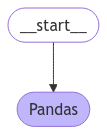

In [10]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
#for event in graph.stream({"messages": [("user", 'cuenta las filas')],
#                           "input":  'hola'}):
#        for value in event.values():
#            print("Assistant:", value["messages"][-1].content)

value = graph.invoke({"messages": [HumanMessage(content="value of VPC")]}
)

print("Assistant:", value["messages"][-1].content)

DEBUG:httpcore.connection:close.started
DEBUG:httpcore.connection:close.complete
DEBUG:httpcore.connection:connect_tcp.started host='192.168.107.42' port=11434 local_address=None timeout=None socket_options=None
DEBUG:httpcore.connection:connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x7ff8dde3ba10>
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'POST']>
DEBUG:httpcore.http11:send_request_headers.complete
DEBUG:httpcore.http11:send_request_body.started request=<Request [b'POST']>
DEBUG:httpcore.http11:send_request_body.complete
DEBUG:httpcore.http11:receive_response_headers.started request=<Request [b'POST']>


INFO ---- [HumanMessage(content='value of VPC', additional_kwargs={}, response_metadata={}, id='22c29089-f7fe-4dff-b8c2-ff4240e45c87')]


> Entering new AgentExecutor chain...


DEBUG:httpcore.http11:receive_response_headers.complete return_value=(b'HTTP/1.1', 200, b'OK', [(b'Content-Type', b'application/x-ndjson'), (b'Date', b'Thu, 30 Jan 2025 11:14:58 GMT'), (b'Transfer-Encoding', b'chunked')])
INFO:httpx:HTTP Request: POST http://192.168.107.42:11434/api/chat "HTTP/1.1 200 OK"
DEBUG:httpcore.http11:receive_response_body.started request=<Request [b'POST']>
DEBUG:httpcore.http11:receive_response_body.complete
DEBUG:httpcore.http11:response_closed.started
DEBUG:httpcore.http11:response_closed.complete
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'POST']>
DEBUG:httpcore.http11:send_request_headers.complete
DEBUG:httpcore.http11:send_request_body.started request=<Request [b'POST']>
DEBUG:httpcore.http11:send_request_body.complete
DEBUG:httpcore.http11:receive_response_headers.started request=<Request [b'POST']>



Invoking: `python_repl_ast` with `{'query': "df['VPC Configuración**: Se configuran varios VPCs']"}`


0    FEX Configuración**: La configuración de FEX (...
1    FEX Configuración**: La configuración de FEX (...
2       VPC Configuración**: Se configuran varios VPCs
Name: VPC Configuración**: Se configuran varios VPCs, dtype: object

DEBUG:httpcore.http11:receive_response_headers.complete return_value=(b'HTTP/1.1', 200, b'OK', [(b'Content-Type', b'application/x-ndjson'), (b'Date', b'Thu, 30 Jan 2025 11:15:06 GMT'), (b'Transfer-Encoding', b'chunked')])
INFO:httpx:HTTP Request: POST http://192.168.107.42:11434/api/chat "HTTP/1.1 200 OK"
DEBUG:httpcore.http11:receive_response_body.started request=<Request [b'POST']>
DEBUG:httpcore.http11:receive_response_body.complete
DEBUG:httpcore.http11:response_closed.started
DEBUG:httpcore.http11:response_closed.complete


The value of "VPC" is "Se configuran varios VPCs".

> Finished chain.
Assistant: The value of "VPC" is "Se configuran varios VPCs".


In [12]:
members = ["network", "pandas"]
def make_supervisor_node(llm: ChatOllama, members: list[str]) -> str:
  options = members + ["FINISH"]

  system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    f" following workers: {members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."    
  )

  class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""
    
    next: Literal["network", "pandas", "FINISH"]

  def supervisor_node(state: MessagesState) -> Command[Literal["network", "pandas", "__end__"]]:
    messages = [
      {"role": "system", "content": system_prompt},
    ] + state["messages"]
    print(f"***Messages :{messages}")

    response = llm2.with_structured_output(Router).invoke(messages)

    print(f"***Response {response}")

    if response is None:
      print("Error: The LLM returned None.")
      print("Messages sent to LLM:", messages)
      raise ValueError("The LLM did not return a valid response.")

    goto = response.get("next")
    if not goto:
      print("Error: 'next' key not found in response.")
      print("Response:", response)
      raise ValueError("'next' key missing in LLM response.")

    goto = response["next"]
    if goto == "FINISH":
      goto = END

    return Command(goto=goto)
  
  return supervisor_node

In [13]:
def pandas_node ( state: MessagesState) -> Command[Literal["supervisor"]]: 
  result = pd_agent.invoke(state["messages"])  
  return Command(
        update={             
            "messages": [
              AIMessage(content=result['output'], name="pandas")
            ],
        },
        goto="supervisor",
    )

In [14]:
import json
from netmiko import ConnectHandler
from langgraph.prebuilt import create_react_agent

def exec_command(ip, command) -> str:
    """
    Connect via SSH to device with ip using the credentials user and password and execute the command

    Args:
      ip (str):
        ip is IP to connect the device    
      command (str):
        command is the command to execute in the device
      Return:
        Json with Output of command, host and command
    """
    nxos_device = {
      'device_type': 'cisco_nxos',
      'host': ip,
      'username': "admin",
      'password': "T3l1ndu5",
      'port': 22,
      'verbose': True
    }
    print(f"IP: {ip} - Command {command}")

    try: 
      connection = ConnectHandler(**nxos_device)
      connection.enable()
      output = connection.send_command(command)
      connection.disconnect()
    except Exception as e:
      connection.disconnect()
      output = "Error: {e}"
      return json.dumps({
        "host": ip,
        "command": command,
        "error": str(e)
      })
    
    return json.dumps({
      "host": ip,
      "command": command,
      "result": output      
    })

system_prompt="You are network engineer. Execute in NXOS devices commands with the exec_command tool "

nx_agent = create_react_agent(
      llm,
      tools=[exec_command], 
      state_modifier=system_prompt
    )

def nx_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    result = nx_agent.invoke(state)
    return Command(
        update={
            "messages": [
                AIMessage(content=result["messages"][-1].content, name="network")
            ]
        },
        goto="supervisor",
    )

In [15]:
builder = StateGraph(MessagesState)
builder.add_edge(START, "supervisor")
builder.add_node("supervisor", make_supervisor_node(llm, members))
builder.add_node("pandas", pandas_node)
builder.add_node("network", nx_node)
grph = builder.compile()

DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): mermaid.ink:443
DEBUG:urllib3.connectionpool:https://mermaid.ink:443 "GET /img/JSV7aW5pdDogeydmbG93Y2hhcnQnOiB7J2N1cnZlJzogJ2xpbmVhcid9fX0lJQpncmFwaCBURDsKCV9fc3RhcnRfXyhbPHA+X19zdGFydF9fPC9wPl0pOjo6Zmlyc3QKCXN1cGVydmlzb3Ioc3VwZXJ2aXNvcikKCXBhbmRhcyhwYW5kYXMpCgluZXR3b3JrKG5ldHdvcmspCglfX2VuZF9fKFs8cD5fX2VuZF9fPC9wPl0pOjo6bGFzdAoJX19zdGFydF9fIC0tPiBzdXBlcnZpc29yOwoJc3VwZXJ2aXNvciAtLi0+IG5ldHdvcms7CglzdXBlcnZpc29yIC0uLT4gcGFuZGFzOwoJc3VwZXJ2aXNvciAtLi0+IF9fZW5kX187CglwYW5kYXMgLS4tPiBzdXBlcnZpc29yOwoJbmV0d29yayAtLi0+IHN1cGVydmlzb3I7CgljbGFzc0RlZiBkZWZhdWx0IGZpbGw6I2YyZjBmZixsaW5lLWhlaWdodDoxLjIKCWNsYXNzRGVmIGZpcnN0IGZpbGwtb3BhY2l0eTowCgljbGFzc0RlZiBsYXN0IGZpbGw6I2JmYjZmYwo=?type=png&bgColor=!white HTTP/1.1" 200 13114


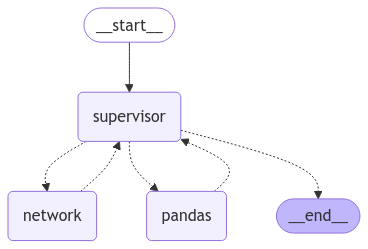

In [16]:
from IPython.display import display, Image

display(Image(grph.get_graph().draw_mermaid_png()))

In [17]:
#value = grph.invoke({"messages": [HumanMessage(content="ask pandas worker to count the rows")]}, {"recursion_limit": 100},debug=True)

value = grph.invoke({"messages": [HumanMessage(content="First ask pandas worker to count the rows.")]}, {"recursion_limit": 100},debug=True)


print("Assistant:", value["messages"][-1].content)

DEBUG:httpcore.connection:connect_tcp.started host='192.168.107.42' port=11434 local_address=None timeout=None socket_options=None
DEBUG:httpcore.connection:connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x7ff8dc0f7a50>
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'POST']>
DEBUG:httpcore.http11:send_request_headers.complete
DEBUG:httpcore.http11:send_request_body.started request=<Request [b'POST']>
DEBUG:httpcore.http11:send_request_body.complete
DEBUG:httpcore.http11:receive_response_headers.started request=<Request [b'POST']>


[-1:checkpoint] State at the end of step -1:
{'messages': []}
[0:tasks] Starting 1 task for step 0:
- __start__ -> {'messages': [HumanMessage(content='First ask pandas worker to count the rows.', additional_kwargs={}, response_metadata={})]}
[0:writes] Finished step 0 with writes to 1 channel:
- messages -> [HumanMessage(content='First ask pandas worker to count the rows.', additional_kwargs={}, response_metadata={})]
[0:checkpoint] State at the end of step 0:
{'messages': [HumanMessage(content='First ask pandas worker to count the rows.', additional_kwargs={}, response_metadata={}, id='2ab65fc3-b865-4f5c-9c6d-05ce8ce7f978')]}
[1:tasks] Starting 1 task for step 1:
- supervisor -> {'messages': [HumanMessage(content='First ask pandas worker to count the rows.', additional_kwargs={}, response_metadata={}, id='2ab65fc3-b865-4f5c-9c6d-05ce8ce7f978')]}
***Messages :[{'role': 'system', 'content': "You are a supervisor tasked with managing a conversation between the following workers: ['networ

DEBUG:httpcore.http11:receive_response_headers.complete return_value=(b'HTTP/1.1', 200, b'OK', [(b'Content-Type', b'application/x-ndjson'), (b'Date', b'Thu, 30 Jan 2025 11:16:58 GMT'), (b'Transfer-Encoding', b'chunked')])
INFO:httpx:HTTP Request: POST http://192.168.107.42:11434/api/chat "HTTP/1.1 200 OK"
DEBUG:httpcore.http11:receive_response_body.started request=<Request [b'POST']>
DEBUG:httpcore.http11:receive_response_body.complete
DEBUG:httpcore.http11:response_closed.started
DEBUG:httpcore.http11:response_closed.complete
DEBUG:httpcore.connection:close.started
DEBUG:httpcore.connection:close.complete
DEBUG:httpcore.connection:connect_tcp.started host='192.168.107.42' port=11434 local_address=None timeout=None socket_options=None
DEBUG:httpcore.connection:connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x7ff8dc0fa7d0>
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'POST']>
DEBUG:httpcore.http11:send_request_headers.complete
DE

***Response {'next': 'pandas'}
[1:writes] Finished step 1 with writes to 0 channels:

[1:checkpoint] State at the end of step 1:
{'messages': [HumanMessage(content='First ask pandas worker to count the rows.', additional_kwargs={}, response_metadata={}, id='2ab65fc3-b865-4f5c-9c6d-05ce8ce7f978')]}
[2:tasks] Starting 1 task for step 2:
- pandas -> {'messages': [HumanMessage(content='First ask pandas worker to count the rows.', additional_kwargs={}, response_metadata={}, id='2ab65fc3-b865-4f5c-9c6d-05ce8ce7f978')]}


> Entering new AgentExecutor chain...


DEBUG:httpcore.http11:receive_response_headers.complete return_value=(b'HTTP/1.1', 200, b'OK', [(b'Content-Type', b'application/x-ndjson'), (b'Date', b'Thu, 30 Jan 2025 11:17:19 GMT'), (b'Transfer-Encoding', b'chunked')])
INFO:httpx:HTTP Request: POST http://192.168.107.42:11434/api/chat "HTTP/1.1 200 OK"
DEBUG:httpcore.http11:receive_response_body.started request=<Request [b'POST']>
DEBUG:httpcore.http11:receive_response_body.complete
DEBUG:httpcore.http11:response_closed.started
DEBUG:httpcore.http11:response_closed.complete
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'POST']>
DEBUG:httpcore.http11:send_request_headers.complete
DEBUG:httpcore.http11:send_request_body.started request=<Request [b'POST']>
DEBUG:httpcore.http11:send_request_body.complete
DEBUG:httpcore.http11:receive_response_headers.started request=<Request [b'POST']>


...

DEBUG:httpcore.http11:receive_response_headers.complete return_value=(b'HTTP/1.1', 200, b'OK', [(b'Content-Type', b'application/x-ndjson'), (b'Date', b'Thu, 30 Jan 2025 11:17:24 GMT'), (b'Transfer-Encoding', b'chunked')])
INFO:httpx:HTTP Request: POST http://192.168.107.42:11434/api/chat "HTTP/1.1 200 OK"
DEBUG:httpcore.http11:receive_response_body.started request=<Request [b'POST']>
DEBUG:httpcore.http11:receive_response_body.complete
DEBUG:httpcore.http11:response_closed.started
DEBUG:httpcore.http11:response_closed.complete
DEBUG:httpcore.connection:close.started
DEBUG:httpcore.connection:close.complete
DEBUG:httpcore.connection:connect_tcp.started host='192.168.107.42' port=11434 local_address=None timeout=None socket_options=None
DEBUG:httpcore.connection:connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x7ff90f29ac10>
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'POST']>
DEBUG:httpcore.http11:send_request_headers.complete
DE

The pandas dataframe `df` has 3 rows.

> Finished chain.
[2:writes] Finished step 2 with writes to 1 channel:
- messages -> [AIMessage(content='The pandas dataframe `df` has 3 rows.', additional_kwargs={}, response_metadata={}, name='pandas')]
[2:checkpoint] State at the end of step 2:
{'messages': [HumanMessage(content='First ask pandas worker to count the rows.', additional_kwargs={}, response_metadata={}, id='2ab65fc3-b865-4f5c-9c6d-05ce8ce7f978'),
              AIMessage(content='The pandas dataframe `df` has 3 rows.', additional_kwargs={}, response_metadata={}, name='pandas', id='f1e8e8c5-8cc1-49e6-b0d2-8bbf8a096265')]}
[3:tasks] Starting 1 task for step 3:
- supervisor -> {'messages': [HumanMessage(content='First ask pandas worker to count the rows.', additional_kwargs={}, response_metadata={}, id='2ab65fc3-b865-4f5c-9c6d-05ce8ce7f978'),
              AIMessage(content='The pandas dataframe `df` has 3 rows.', additional_kwargs={}, response_metadata={}, name='pandas', id='f1e8e8c5

DEBUG:httpcore.http11:receive_response_headers.complete return_value=(b'HTTP/1.1', 200, b'OK', [(b'Content-Type', b'application/x-ndjson'), (b'Date', b'Thu, 30 Jan 2025 11:17:30 GMT'), (b'Transfer-Encoding', b'chunked')])
INFO:httpx:HTTP Request: POST http://192.168.107.42:11434/api/chat "HTTP/1.1 200 OK"
DEBUG:httpcore.http11:receive_response_body.started request=<Request [b'POST']>
DEBUG:httpcore.http11:receive_response_body.complete
DEBUG:httpcore.http11:response_closed.started
DEBUG:httpcore.http11:response_closed.complete


***Response None
Error: The LLM returned None.
Messages sent to LLM: [{'role': 'system', 'content': "You are a supervisor tasked with managing a conversation between the following workers: ['network', 'pandas']. Given the following user request, respond with the worker to act next. Each worker will perform a task and respond with their results and status. When finished, respond with FINISH."}, HumanMessage(content='First ask pandas worker to count the rows.', additional_kwargs={}, response_metadata={}, id='2ab65fc3-b865-4f5c-9c6d-05ce8ce7f978'), AIMessage(content='The pandas dataframe `df` has 3 rows.', additional_kwargs={}, response_metadata={}, name='pandas', id='f1e8e8c5-8cc1-49e6-b0d2-8bbf8a096265')]


ValueError: The LLM did not return a valid response.